<a href="https://colab.research.google.com/github/ajstark-ualr/AI-whispers/blob/master/BM_Workshop_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install kaiwu pytorch plugin

In [ ]:
!pip install kaiwu-1.3.1-py3-none-any.whl
!git clone https://github.com/QBoson/Kaiwu-pytorch-plugin.git

Processing ./kaiwu-1.3.1-py3-none-any.whl
kaiwu is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
fatal: destination path 'Kaiwu-pytorch-plugin' already exists and is not an empty directory.


Running in Termial!!!

In [ ]:
!cd /content/Kaiwu-pytorch-plugin
!pip install -r /content/Kaiwu-pytorch-plugin/requirements/requirements.txt
!pip install .

# Submit Test Case

In [ ]:
# pylint: disable=<R0801>
"""
TSP problem solved using CIM.
"""
import numpy as np
import pandas as pd
import kaiwu as kw
import kaiwu.core._binary_expression


def is_edge_used(var_x, var_u, var_v):
    """
    Determine whether the edge (u, v) is used in the path.

    Args:
        var_x (ndarray): Decision variable matrix.

        var_u (int): Start node.

        var_v (int): End node.

    Returns:
        ndarray: Decision variable corresponding to the edge (u, v).
    """
    return kaiwu.core.quicksum([var_x[var_u, j] * var_x[var_v, j + 1] for j in range(-1, n - 1)])


if __name__ == '__main__':
    # Import distance matrix
    # Set the save path for intermediate files
    kw.common.CheckpointManager.save_dir = '/tmp'
    # Define distance matrix

    # rng = np.random.default_rng(42)

    # upper = np.triu(rng.integers(0, 2, size=(11, 11)), k=1)
    # w = upper + upper.T
    # print(w)
    # print(w.shape)
    w = np.array([[0, 1, 2],
                  [1, 0, 0],
                  [2, 0, 0]])
    # Get the number of nodes
    n = w.shape[0]

    # Create qubo variable matrix
    x = kaiwu.core.ndarray((n, n), "x", kaiwu.core.Binary)

    # Get sets of edge and non-edge pairs
    edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]
    no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]

    qubo_model = kw.qubo.QuboModel()
    # TSP path cost
    qubo_model.set_objective(
        kaiwu.core.quicksum([w[u, v] * is_edge_used(x, u, v) for u, v in edges]))

    # Node constraint: Each node must belong to exactly one position
    qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "sequence_cons", penalty=5.0)

    # Position constraint: Each position can have only one node
    qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "node_cons", penalty=5.0)

    # Edge constraint: Pairs without edges cannot appear in the path
    qubo_model.add_constraint(kaiwu.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges]) == 0,
        "connect_cons", penalty=20)

    qubo_mat = qubo_model.get_matrix()
    print(qubo_mat)
    # cim_input = kw.ising.adjust_ising_matrix_precision(qubo_mat, 8)
    # print(cim_input)
    pd.DataFrame(qubo_mat).to_csv("tsp.csv", index=False, header=False)


[[-10.  30.  30.  10.   1.   1.  10.   2.   2.]
 [  0. -10.  30.   1.  10.   1.   2.  10.   2.]
 [  0.   0. -10.   1.   1.  10.   2.   2.  10.]
 [  0.   0.   0. -10.  30.  30.  10.  20.  20.]
 [  0.   0.   0.   0. -10.  30.  20.  10.  20.]
 [  0.   0.   0.   0.   0. -10.  20.  20.  10.]
 [  0.   0.   0.   0.   0.   0. -10.  30.  30.]
 [  0.   0.   0.   0.   0.   0.   0. -10.  30.]
 [  0.   0.   0.   0.   0.   0.   0.   0. -10.]]


In [ ]:
"""
TSP calling CIM example
"""
import kaiwu as kw
import numpy as np
from kaiwu.common import CheckpointManager as ckpt

# Define edges using conditional functions
def is_edge_used(var_x, var_u, var_v):
    """
    Determine whether the edge (u, v) is used in the path.

    Args:
        var_x (ndarray): Decision variable matrix.

        var_u (int): Start node.

        var_v (int): End node.

    Returns:
        ndarray: Decision variable corresponding to the edge (u, v).
    """
    return kw.core.quicksum([var_x[var_u, j] * var_x[var_v, j + 1] for j in range(-1, n - 1)])


if __name__ == "__main__":
    # Set the save path for intermediate files
    kw.common.CheckpointManager.save_dir = '/tmp'
    # Define distance matrix

    rng = np.random.default_rng(42)

    upper = np.triu(rng.integers(0, 2, size=(11, 11)), k=1)
    w = upper + upper.T
    print(w)
    print(w.shape)  # (101, 101)

    n = w.shape[0]  # Number of nodes

    # Create a QUBO variable matrix (n x n)
    x = kw.core.ndarray((n, n), "x", kw.core.Binary)

    # Generate the set of edges and the set of non-edges
    edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] != 0]
    no_edges = [(u, v) for u in range(n) for v in range(n) if w[u, v] == 0]

    # Initialize the QUBO model
    qubo_model = kw.qubo.QuboModel()

    # Set the objective function: minimize path cost
    path_cost = kw.core.quicksum([w[u, v] * is_edge_used(x, u, v) for u, v in edges])
    qubo_model.set_objective(path_cost)

    # Add constraints
    # Node constraints: Each node must occupy one position
    qubo_model.add_constraint((x.sum(axis=0) - 1) ** 2 == 0, "node_cons", penalty=5.0)

    # Location constraint: Each location must have at least one node.
    qubo_model.add_constraint((x.sum(axis=1) - 1) ** 2 == 0, "pos_cons", penalty=5.0)

    # Edge constraint: Non-connecting edges must not appear
    qubo_model.add_constraint(
        kw.core.quicksum([is_edge_used(x, u, v) for u, v in no_edges])==0,
        "edge_cons", penalty=5
    )
    print("begin")
    # Configure the solver
    ckpt.save_dir = './tmp'
    optimizer = kw.cim.CIMOptimizer(task_name="tsp_test",wait=True)
    print("begin")
    optimizer = kw.cim.PrecisionReducer(optimizer,8,truncated_precision=8,)
    print("begin")
    solver = kw.solver.SimpleSolver(optimizer)
    #solver = optimizer.core.Solver(optimizer)
    print("begin")

    sol_dict, qubo_val = solver.solve_qubo(qubo_model)

    if sol_dict is not None:
        # Verification Results
        unsatisfied, res_dict = qubo_model.verify_constraint(sol_dict)
        print(f"Number of unsatisfied constraints: {unsatisfied}")
        print(f"constraint value: {res_dict}")

        # Calculate path cost
        path_cost = kw.core.get_val(qubo_model.objective, sol_dict)
        print(f"Actual path cost: {path_cost}")
    else:
        print("Try again later")

[[0 1 1 0 0 1 0 1 0 0 1]
 [1 0 1 1 1 1 0 1 0 1 0]
 [1 1 0 1 0 1 1 0 0 0 0]
 [0 1 1 0 1 0 1 0 1 1 0]
 [0 1 0 1 0 1 1 0 0 0 0]
 [1 1 1 0 1 0 1 0 1 0 0]
 [0 0 1 1 1 1 0 0 1 0 0]
 [1 1 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 1 1 1 0 1 1]
 [0 1 0 1 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 0 0 1 1 0]]
(11, 11)
begin
begin
begin
begin
[2026-06-24 03:36:01] [INFO    ] [kaiwu.cim._optimizer_adapter:197] - Task calculation successful!, Task name: tsp_test
Number of unsatisfied constraints: 22
constraint value: {'constraint0': np.float64(1.0), 'constraint2': np.float64(1.0), 'constraint4': np.float64(1.0), 'constraint6': np.float64(1.0), 'constraint8': np.float64(1.0), 'constraint10': np.float64(1.0), 'constraint12': np.float64(1.0), 'constraint14': np.float64(1.0), 'constraint16': np.float64(1.0), 'constraint18': np.float64(1.0), 'constraint20': np.float64(1.0), 'constraint11': np.float64(1.0), 'constraint13': np.float64(1.0), 'constraint15': np.float64(1.0), 'constraint17': np.float64(1.0), 'constraint19': np.float

# Binder Kit

In [ ]:

import numpy as np

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"               # 20 standard residues
AA_TO_ID = {aa: i for i, aa in enumerate(AMINO_ACIDS)}   # A->0 ... Y->19
ID_TO_AA = {i: aa for aa, i in AA_TO_ID.items()}
PAD_ID = 20                                         # padding token id (-> "10100")
BITS_PER_TOKEN = 5                                  # 5 bits hold 0..31, we use 0..20


def id_to_bits(token_id: int) -> list[int]:
    """0..20 -> 5-bit list, e.g. 1 -> [0,0,0,0,1], 20 -> [1,0,1,0,0]."""
    return [int(b) for b in format(token_id, "05b")]


def encode_sequence(seq: str, max_len: int = 50, pad_side: str = "left") -> np.ndarray:
    """One peptide string -> a (max_len * 5,) array of 0/1 ints (left-padded)."""
    ids = [AA_TO_ID[a] for a in seq.upper()][:max_len]
    pad = [PAD_ID] * (max_len - len(ids))
    ids = pad + ids if pad_side == "left" else ids + pad
    bits: list[int] = []
    for tid in ids:
        bits.extend(id_to_bits(tid))
    return np.asarray(bits, dtype=np.int64)


def encode_sequences(seqs, max_len: int = 50, pad_side: str = "left") -> np.ndarray:
    """List of peptides -> (n_seqs, max_len*5) 0/1 matrix."""
    return np.stack([encode_sequence(s, max_len, pad_side) for s in seqs])


def decode_bits(bits) -> str:
    """A flat 0/1 vector -> peptide string. 5-bit groups decoding to >= 20 (PAD or
    unused 21..31) are skipped."""
    bits = np.asarray(bits).astype(int).ravel()
    out = []
    for s in range(0, len(bits) - BITS_PER_TOKEN + 1, BITS_PER_TOKEN):
        tid = int("".join(str(int(b)) for b in bits[s:s + BITS_PER_TOKEN]), 2)
        if tid < 20:
            out.append(ID_TO_AA[tid])
    return "".join(out)


def decode_samples(samples, num_visible: int = 250) -> list[str]:
    """Decode a batch of 0/1 model samples (N, num_nodes) into peptide strings."""
    arr = np.asarray(samples)
    return [decode_bits(row[:num_visible]) for row in arr]
# ====== 只需要在最底下加上这两行 ======
import sys
sys.modules['bk'] = sys.modules[__name__]


# kaiwu

In [ ]:
import collections
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
import torch
from torch.optim import SGD

import kaiwu as kw
from kaiwu.torch_plugin import BoltzmannMachine
import binder_kit as bk
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# import binder_kit as bk
os.environ["KAIWU_USER_ID"]="156024923108671490"
os.environ["KAIWU_SDK_CODE"]="4UwSAJMjwpS1FCxQxH22NHsEhwSaEk"
torch.cuda.is_available = lambda: False
np.random.seed(0); torch.manual_seed(0)            # reproducible runs
kw.license.init(int(os.environ["KAIWU_USER_ID"]), os.environ["KAIWU_SDK_CODE"])
print("kaiwu", kw.__version__, "| torch", torch.__version__, "— license initialized")

kaiwu 1.3.1 | torch 2.11.0+cu128 — license initialized


A -> [0, 0, 0, 0, 0] | Y -> [1, 0, 0, 1, 1] | PAD -> [1, 0, 1, 0, 0]
round-trip: ['ACDEFG', 'WYKR', 'GGGSGGGS'] -> (3, 60) bits -> ['ACDEFG', 'WYKR', 'GGGSGGGS']


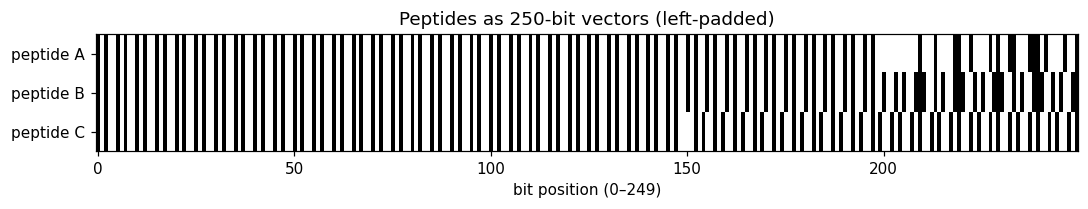

In [ ]:
print("A ->", bk.id_to_bits(bk.AA_TO_ID["A"]),
      "| Y ->", bk.id_to_bits(bk.AA_TO_ID["Y"]),
      "| PAD ->", bk.id_to_bits(bk.PAD_ID))

demo = ["ACDEFG", "WYKR", "GGGSGGGS"]
enc = bk.encode_sequences(demo, max_len=12)
assert [bk.decode_bits(r) for r in enc] == demo
print("round-trip:", demo, "->", enc.shape, "bits ->", [bk.decode_bits(r) for r in enc])

bar = bk.encode_sequences(["ACDEFGHIKL", "WYWYWYWYWY", "GGGGGGGGGGGGGGGGGGGG"], max_len=50)
plt.figure(figsize=(10, 2))
plt.imshow(bar, aspect="auto", cmap="gray_r", interpolation="nearest")
plt.yticks([0, 1, 2], ["peptide A", "peptide B", "peptide C"])
plt.xlabel("bit position (0–249)"); plt.title("Peptides as 250-bit vectors (left-padded)")
plt.tight_layout(); plt.show()

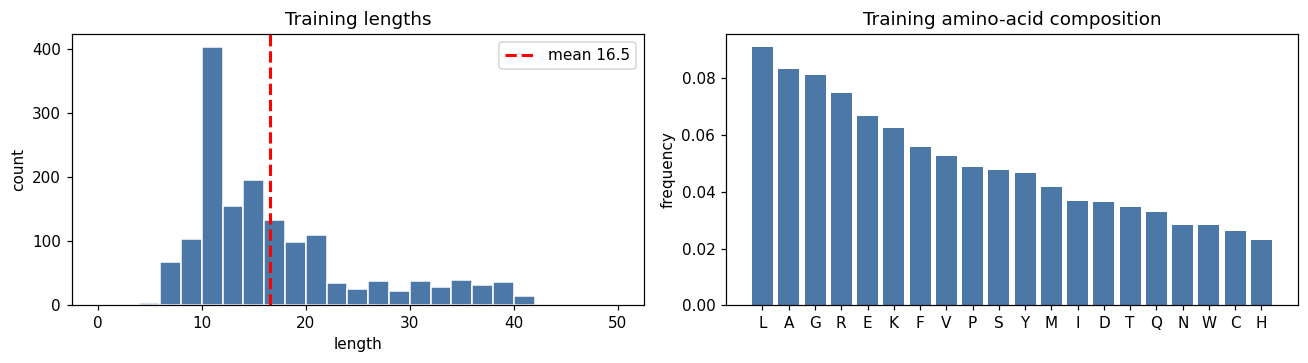

1574 binders, each 250 bits


In [ ]:
train_bits = np.load("data/seqs250bit_1574.npy").astype(np.float32)
train_seqs = [bk.decode_bits(r) for r in train_bits]
train_len = np.array([len(s) for s in train_seqs])

def aa_freq(seqs):
    c = collections.Counter("".join(seqs)); t = sum(c.values()) or 1
    return np.array([c.get(a, 0) / t for a in bk.AMINO_ACIDS])
ft = aa_freq(train_seqs)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(train_len, bins=range(0, 52, 2), color="#4C78A8", edgecolor="white")
ax[0].axvline(train_len.mean(), color="red", ls="--", lw=2, label=f"mean {train_len.mean():.1f}")
ax[0].set_xlabel("length"); ax[0].set_ylabel("count"); ax[0].set_title("Training lengths"); ax[0].legend()
order = np.argsort(-ft)
ax[1].bar([bk.AMINO_ACIDS[i] for i in order], ft[order], color="#4C78A8")
ax[1].set_title("Training amino-acid composition"); ax[1].set_ylabel("frequency")
plt.tight_layout(); plt.show()
print(f"{train_bits.shape[0]} binders, each {train_bits.shape[1]} bits")

BoltzmannMachine: 356 nodes | 127092 parameters


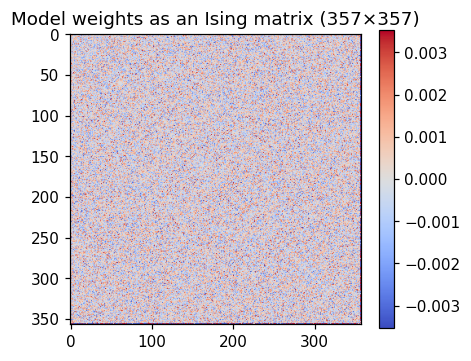

In [ ]:
NUM_VISIBLE, NUM_HIDDEN = 256, 100
bm = BoltzmannMachine(NUM_VISIBLE + NUM_HIDDEN)
print("BoltzmannMachine:", NUM_VISIBLE + NUM_HIDDEN, "nodes |",
      sum(p.numel() for p in bm.parameters()), "parameters")

ising = bm.get_ising_matrix()                       # the model's weights (float)
plt.figure(figsize=(4.2, 3.8))
sc = np.percentile(np.abs(ising[ising != 0]), 99) if np.any(ising != 0) else 1
plt.imshow(ising, cmap="coolwarm", vmin=-sc, vmax=sc)
plt.title(f"Model weights as an Ising matrix ({ising.shape[0]}×{ising.shape[0]})")
plt.colorbar(shrink=0.8); plt.tight_layout(); plt.show()

In [ ]:
# SA sampler — same settings as the original bm_generation example (size_limit=10):
sa = kw.classical.SimulatedAnnealingOptimizer(
    initial_temperature=100, alpha=0.9, cutoff_temperature=1e-2,
    iterations_per_t=200, size_limit=10, rand_seed=1234)

# CIM on real hardware. PrecisionReducer quantizes the weight matrix to 8-bit
# integers before submitting — that quantized matrix is what the hardware solves.
kw.common.CheckpointManager.save_dir = "./_kaiwu_tasks"
cim = kw.cim.PrecisionReducer(
    kw.cim.CIMOptimizer(task_name="BM_workshop", wait=True,task_mode='quota'),
    precision=8, truncated_precision=10, only_feasible_solution=False)

cim_input = kw.ising.adjust_ising_matrix_precision(bm.get_ising_matrix(), 8)
print("model weights (float) ->", bm.get_ising_matrix().dtype,
      "| what the CIM receives ->", cim_input.dtype,
      f"in range {int(cim_input.min())}..{int(cim_input.max())}")

model weights (float) -> float32 | what the CIM receives -> int64 in range -120..127


In [ ]:
opt = SGD(bm.parameters(), lr=0.05)
sampler = cim                                   # set to `cim` to train on the QPU
MAX_STEPS, BATCH = 2, 15

e_data, e_model = [], []
for step in range(MAX_STEPS):
    batch = torch.tensor(train_bits[np.random.choice(len(train_bits), BATCH)])
    x = bm.condition_sample(sampler, batch)    # data (positive) phase
    s = bm.sample(sampler)                      # model (negative) phase
    ex, es = bm.forward(x).mean(), bm.forward(s).mean()
    objective = ex - es                         # == bm.objective(x, s)
    opt.zero_grad()
    objective.backward()
    opt.step()
    bm.clip_parameters(h_range=(-1, 1), j_range=(-1, 1))
    e_data.append(ex.item()); e_model.append(es.item())
    if step % 1 == 0 or step == MAX_STEPS - 1:
        print(f"  step {step:3d}  E(data)={ex.item():8.1f}  E(model)={es.item():8.1f}  "
              f"objective={objective.item():7.1f}")

plt.figure(figsize=(7, 3))
plt.plot(e_data, color="#1f77b4", label="E(data) — positive phase")
plt.plot(e_model, color="#ff7f0e", label="E(model) — negative phase (annealer minimum)")
plt.xlabel("training step"); plt.ylabel("energy"); plt.legend()
plt.title("The objective is the gap  E(data) − E(model)")
plt.tight_layout(); plt.show()

TypeError: disable() got an unexpected keyword argument 'wrapping'

In [ ]:
H = np.genfromtxt("checkpoints/binder/H.csv", delimiter=",")
J = np.genfromtxt("checkpoints/binder/J.csv", delimiter=",")
trained = BoltzmannMachine(NUM_VISIBLE + NUM_HIDDEN)
with torch.no_grad():
    trained.linear_bias.copy_(torch.tensor(-H, dtype=torch.float32))
    trained.quadratic_coef.copy_(torch.tensor(-2 * np.triu(J, 1), dtype=torch.float32))

# Each SA call returns size_limit=10 samples (as in the original); accumulate over
# 30 independent anneals to build a candidate library.
gen_peps = []
for r in range(30):
    sampler_r = kw.classical.SimulatedAnnealingOptimizer(
        initial_temperature=100, alpha=0.9, cutoff_temperature=1e-2,
        iterations_per_t=200, size_limit=10, rand_seed=r)
    gen_peps += [p for p in bk.decode_samples(trained.sample(sampler_r).detach().numpy()) if p]
gen_peps = list(dict.fromkeys(gen_peps))
print(f"SA generated {len(gen_peps)} unique peptides over 30 rounds, e.g. {gen_peps[:6]}")

RuntimeError: The size of tensor a (356) must match the size of tensor b (350) at non-singleton dimension 0

In [ ]:
#Real CIM hardware (one task, sample_number=10):
pep_cim = [p for p in bk.decode_samples(trained.sample(cim).detach().numpy()) if p]
print(f"CIM generated {len(set(pep_cim))} unique peptides, "
      f"e.g. {list(dict.fromkeys(pep_cim))[:6]}")

In [ ]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit_transform(self, X):
        # 中心化数据
        mean = np.mean(X, axis=0)
        X_centered = X - mean

        # 计算协方差矩阵
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 计算特征值和特征向量
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 按特征值降序排列
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvectors_sorted = eigenvectors[:, sorted_indices]

        # 取前 n_components 个特征向量
        components = eigenvectors_sorted[:, :self.n_components]

        # 投影数据
        return np.dot(X_centered, components)


In [ ]:
gen = list(dict.fromkeys(gen_peps))
train_set = set(train_seqs)
novel = sum(p not in train_set for p in gen)
fg = aa_freq(gen)
print(f"generated: {len(gen)} unique | {100*novel/len(gen):.0f}% novel | "
      f"amino-acid composition corr vs training {np.corrcoef(ft, fg)[0,1]:.2f}")

# Length and amino-acid composition: training (blue) vs generated (orange).
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(train_len, bins=range(0, 52, 2), alpha=0.6, label="training", color="#1f77b4")
ax[0].hist([len(p) for p in gen], bins=range(0, 52, 2), alpha=0.6, label="generated", color="#ff7f0e")
ax[0].set_xlabel("length"); ax[0].set_ylabel("count")
ax[0].set_title("Length: training vs generated"); ax[0].legend()
x = np.arange(20)
ax[1].bar(x - 0.2, ft, 0.4, label="training", color="#1f77b4")
ax[1].bar(x + 0.2, fg, 0.4, label="generated", color="#ff7f0e")
ax[1].set_xticks(x); ax[1].set_xticklabels(list(bk.AMINO_ACIDS), fontsize=8)
ax[1].set_title(f"Amino-acid composition (corr = {np.corrcoef(ft, fg)[0,1]:.2f})"); ax[1].legend()
plt.tight_layout(); plt.show()

# 3-mer-frequency PCA: training / generated / random.
rng = np.random.default_rng(0)
rand = ["".join(rng.choice(list(bk.AMINO_ACIDS), size=int(L))) for L in rng.choice(train_len, 300)]
groups = [train_seqs[:300], gen[:300], rand]
labels = ["training", "generated", "random"]
colors = ["#1f77b4", "#ff7f0e", "#7f7f7f"]
vocab = {}
for g in groups:
    for s in g:
        for i in range(len(s) - 2):
            vocab.setdefault(s[i:i+3], len(vocab))
def vec(s):
    v = np.zeros(len(vocab))
    for i in range(len(s) - 2):
        v[vocab[s[i:i+3]]] += 1
    return v / (len(s) - 2 + 1e-8)
X = np.array([vec(s) for g in groups for s in g if len(s) > 2])
y = np.array([gi for gi, g in enumerate(groups) for s in g if len(s) > 2])
XP = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(6, 5))
for gi in range(3):
    m = y == gi
    plt.scatter(XP[m, 0], XP[m, 1], c=colors[gi], label=labels[gi],
                s=40, alpha=0.4, edgecolors="black", linewidth=0.3)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("3-mer PCA: generated lands on training, away from random")
plt.tight_layout(); plt.show()